In [1]:
# FEATURE ENGINEERING 
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# Load your correctly imputed data
train_path = r"D:\bhopal-pollutant-prediction\processed_data\bhopal_train_imputed_correct.csv"
test_path = r"D:\bhopal-pollutant-prediction\processed_data\bhopal_test_imputed_correct.csv"

train = pd.read_csv(train_path, parse_dates=['datetime'], index_col='datetime')
test = pd.read_csv(test_path, parse_dates=['datetime'], index_col='datetime')

print("=" * 60)
print("FEATURE ENGINEERING FOR POLLUTANT PREDICTION")
print("=" * 60)
print(f"Train shape: {train.shape} | {train.index.min()} to {train.index.max()}")
print(f"Test shape: {test.shape} | {test.index.min()} to {test.index.max()}")
print(f"Total features: {train.shape[1]}")

FEATURE ENGINEERING FOR POLLUTANT PREDICTION
Train shape: (13632, 49) | 2024-01-01 00:00:00 to 2025-07-21 23:00:00
Test shape: (3408, 49) | 2025-07-22 00:00:00 to 2025-12-10 23:00:00
Total features: 49


In [2]:
#  IDENTIFY COLUMNS 
# Pollutant columns (targets)
aqi_cols = [c for c in train.columns if any(p in c for p in 
            ['PM25','PM10','NO','NO2','SO2','CO','O3','NH3','Benzene'])]

# Weather columns (features)
weather_cols = [c for c in train.columns if c in [
    'temp','feelslike','dew','humidity','precip','precipprob',
    'windspeed','winddir','windgust','sealevelpressure',
    'cloudcover','visibility','solarradiation','uvindex'
]]

# Time features
time_cols = ['year', 'month', 'day', 'hour', 'dayofweek', 
             'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

print(f"Pollutant columns: {len(aqi_cols)} (TARGETS)")
print(f"Weather columns: {len(weather_cols)} (FEATURES)")
print(f"Time features: {len(time_cols)} (FEATURES)")
print(f"Total initial columns: {len(aqi_cols) + len(weather_cols) + len(time_cols)}")

# Select primary targets (focus on key pollutants)
primary_targets = [
    'PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills',
    'PM25_TT_Nagar', 'PM10_TT_Nagar',
    'PM25_Paryavaran_Parisar', 'PM10_Paryavaran_Parisar'
]

print(f"\nPrimary targets: {primary_targets}")

Pollutant columns: 26 (TARGETS)
Weather columns: 14 (FEATURES)
Time features: 9 (FEATURES)
Total initial columns: 49

Primary targets: ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills', 'PM25_TT_Nagar', 'PM10_TT_Nagar', 'PM25_Paryavaran_Parisar', 'PM10_Paryavaran_Parisar']


In [3]:
#  CREATE LAG FEATURES 
print("\n" + "=" * 60)
print("CREATING LAG FEATURES")
print("=" * 60)

def create_lag_features(df, columns, lags=[1, 2, 3, 6, 12, 24]):
    """Create lag features for specified columns"""
    df_lagged = df.copy()
    
    for col in columns:
        for lag in lags:
            df_lagged[f'{col}_lag_{lag}h'] = df[col].shift(lag)
    
    return df_lagged

# Apply to train and test
lags = [1, 2, 3, 6, 12, 24]  # Hours

print(f"Creating lag features with lags: {lags} hours")
train_lagged = create_lag_features(train, primary_targets, lags)
test_lagged = create_lag_features(test, primary_targets, lags)

print(f"Train after lag: {train_lagged.shape}")
print(f"Test after lag: {test_lagged.shape}")


CREATING LAG FEATURES
Creating lag features with lags: [1, 2, 3, 6, 12, 24] hours
Train after lag: (13632, 91)
Test after lag: (3408, 91)


In [4]:
#  CREATE ROLLING FEATURES 
print("\n" + "=" * 60)
print("CREATING ROLLING STATISTICS")
print("=" * 60)

def create_rolling_features(df, columns, windows=[3, 6, 12, 24]):
    """Create rolling statistics for specified columns"""
    df_rolling = df.copy()
    
    for col in columns:
        for window in windows:
            df_rolling[f'{col}_roll_mean_{window}h'] = df[col].rolling(window=window, min_periods=1).mean()
            df_rolling[f'{col}_roll_std_{window}h'] = df[col].rolling(window=window, min_periods=1).std()
            df_rolling[f'{col}_roll_max_{window}h'] = df[col].rolling(window=window, min_periods=1).max()
            df_rolling[f'{col}_roll_min_{window}h'] = df[col].rolling(window=window, min_periods=1).min()
    
    return df_rolling

# Apply rolling features to targets
windows = [3, 6, 12]  # Hours (smaller windows to avoid too many features)

print(f"Creating rolling features with windows: {windows} hours")
train_rolled = create_rolling_features(train_lagged, primary_targets, windows)
test_rolled = create_rolling_features(test_lagged, primary_targets, windows)

print(f"Train after rolling: {train_rolled.shape}")
print(f"Test after rolling: {test_rolled.shape}")


CREATING ROLLING STATISTICS
Creating rolling features with windows: [3, 6, 12] hours
Train after rolling: (13632, 175)
Test after rolling: (3408, 175)


In [5]:
# CREATE TIME-BASED FEATURES 
print("\n" + "=" * 60)
print("ENHANCING TIME FEATURES")
print("=" * 60)

def enhance_time_features(df):
    """Add additional time-based features"""
    df_time = df.copy()
    
    # Already have: hour_sin, hour_cos, month_sin, month_cos
    
    # Add more specific time features
    df_time['hour_of_day'] = df_time.index.hour
    df_time['day_of_week'] = df_time.index.dayofweek
    df_time['day_of_month'] = df_time.index.day
    df_time['week_of_year'] = df_time.index.isocalendar().week
    
    # Time periods
    df_time['is_weekend'] = df_time['day_of_week'].isin([5, 6]).astype(int)
    df_time['is_night'] = ((df_time['hour_of_day'] >= 22) | (df_time['hour_of_day'] <= 5)).astype(int)
    df_time['is_morning_rush'] = ((df_time['hour_of_day'] >= 7) & (df_time['hour_of_day'] <= 10)).astype(int)
    df_time['is_evening_rush'] = ((df_time['hour_of_day'] >= 17) & (df_time['hour_of_day'] <= 20)).astype(int)
    
    # Season
    df_time['season'] = df_time['month'] % 12 // 3 + 1  # 1:Winter, 2:Spring, 3:Summer, 4:Fall
    
    return df_time

train_final = enhance_time_features(train_rolled)
test_final = enhance_time_features(test_rolled)

print(f"Train final shape: {train_final.shape}")
print(f"Test final shape: {test_final.shape}")
print(f"Total features created: {train_final.shape[1] - train.shape[1]}")


ENHANCING TIME FEATURES
Train final shape: (13632, 184)
Test final shape: (3408, 184)
Total features created: 135


In [6]:
#  HANDLE NaN FROM LAG/ROLLING 
print("\n" + "=" * 60)
print("HANDLING NaN FROM FEATURE ENGINEERING")
print("=" * 60)

# Count NaN before cleanup
train_nan_before = train_final.isnull().sum().sum()
test_nan_before = test_final.isnull().sum().sum()

print(f"NaN before cleanup: Train={train_nan_before}, Test={test_nan_before}")

# Fill NaN from lag/rolling features
train_final = train_final.fillna(method='bfill').fillna(method='ffill')
test_final = test_final.fillna(method='bfill').fillna(method='ffill')

train_nan_after = train_final.isnull().sum().sum()
test_nan_after = test_final.isnull().sum().sum()

print(f"NaN after cleanup: Train={train_nan_after}, Test={test_nan_after}")
print(f"Rows dropped due to NaN: Train={len(train) - len(train_final)}, Test={len(test) - len(test_final)}")


HANDLING NaN FROM FEATURE ENGINEERING
NaN before cleanup: Train=357, Test=357
NaN after cleanup: Train=0, Test=0
Rows dropped due to NaN: Train=0, Test=0


C:\Users\MADHURA\AppData\Local\Temp\ipykernel_14080\655100662.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_final = train_final.fillna(method='bfill').fillna(method='ffill')
C:\Users\MADHURA\AppData\Local\Temp\ipykernel_14080\655100662.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_final = test_final.fillna(method='bfill').fillna(method='ffill')


In [7]:
#  SAVE ENGINEERED FEATURES 
print("\n" + "=" * 60)
print("SAVING ENGINEERED DATASETS")
print("=" * 60)

# Save engineered datasets
train_save_path = r"D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv"
test_save_path = r"D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv"

train_final.to_csv(train_save_path)
test_final.to_csv(test_save_path)

print(f"✓ Saved engineered train: {train_save_path}")
print(f"  Shape: {train_final.shape}")
print(f"  Size: {train_final.memory_usage().sum() / (1024**2):.1f} MB")

print(f"\n✓ Saved engineered test: {test_save_path}")
print(f"  Shape: {test_final.shape}")
print(f"  Size: {test_final.memory_usage().sum() / (1024**2):.1f} MB")

# Save feature list for reference
feature_columns = [col for col in train_final.columns if col not in aqi_cols]
target_columns = aqi_cols

feature_info = pd.DataFrame({
    'feature_type': ['original'] * len(aqi_cols + weather_cols + time_cols) + 
                   ['lag'] * (len(train_final.columns) - len(train.columns)),
    'column_name': list(train.columns) + 
                   list(set(train_final.columns) - set(train.columns))
})

feature_info.to_csv(r"D:\bhopal-pollutant-prediction\processed_data\feature_info.csv", index=False)
print(f"\n✓ Saved feature information")


SAVING ENGINEERED DATASETS
✓ Saved engineered train: D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv
  Shape: (13632, 184)
  Size: 19.0 MB

✓ Saved engineered test: D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv
  Shape: (3408, 184)
  Size: 4.8 MB

✓ Saved feature information



FEATURE CORRELATION ANALYSIS


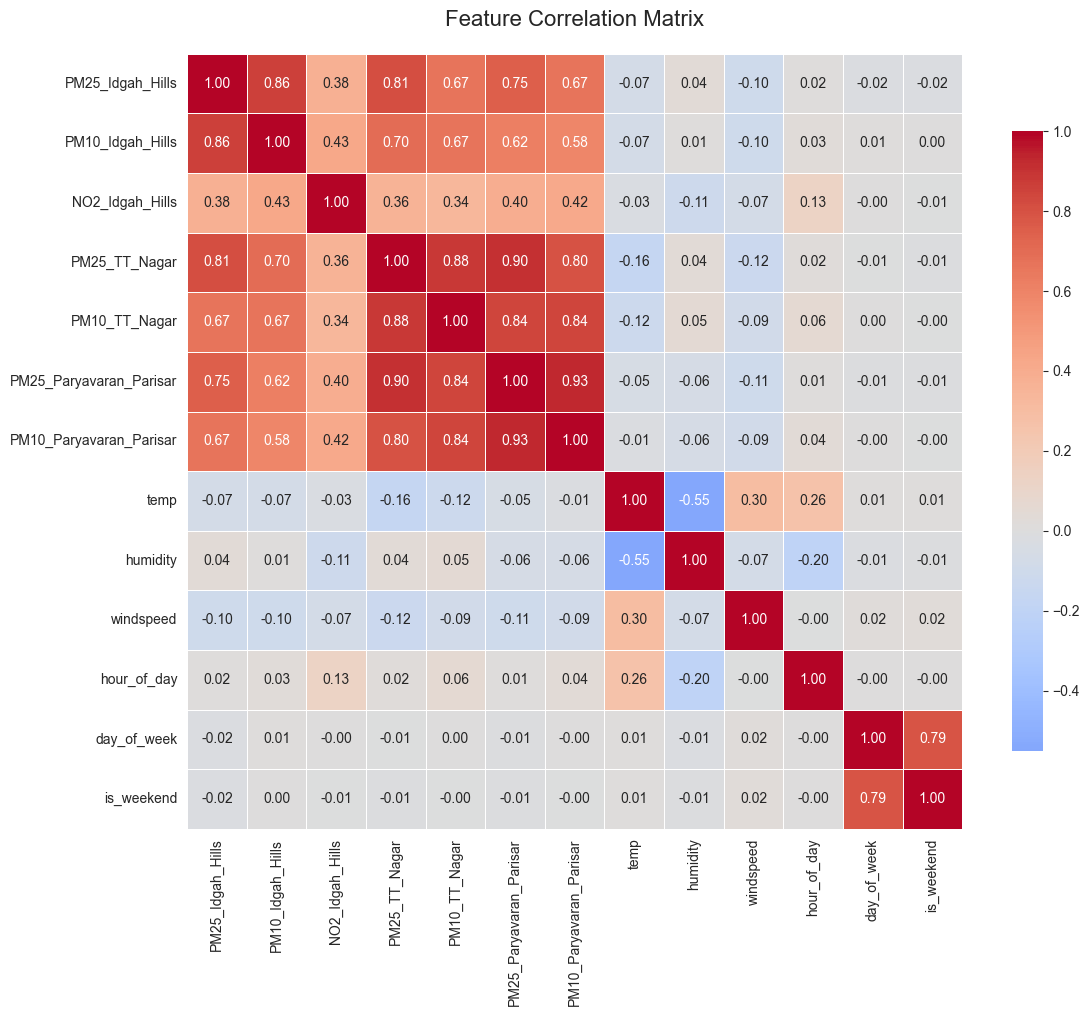


Top correlations with PM25_Idgah_Hills:
PM25_Idgah_Hills           1.000000
PM10_Idgah_Hills           0.862728
PM25_TT_Nagar              0.812805
PM25_Paryavaran_Parisar    0.749975
PM10_Paryavaran_Parisar    0.670660
PM10_TT_Nagar              0.668062
NO2_Idgah_Hills            0.380513
humidity                   0.041168
hour_of_day                0.016284
day_of_week               -0.019501
Name: PM25_Idgah_Hills, dtype: float64


In [8]:
#  VISUALIZE FEATURE CORRELATIONS 
print("\n" + "=" * 60)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 60)

import matplotlib.pyplot as plt

# Select subset of features for correlation matrix
sample_features = primary_targets + ['temp', 'humidity', 'windspeed', 
                                     'hour_of_day', 'day_of_week', 'is_weekend']

# Calculate correlation
correlation_matrix = train_final[sample_features].corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Top correlations with PM2.5
print("\nTop correlations with PM25_Idgah_Hills:")
pm25_corrs = correlation_matrix['PM25_Idgah_Hills'].sort_values(ascending=False)
print(pm25_corrs.head(10))

In [9]:
#  FINAL SUMMARY 
print("\n" + "=" * 60)
print("FEATURE ENGINEERING COMPLETE - SUMMARY")
print("=" * 60)

print(f"📊 DATASET SIZES:")
print(f"  Train: {train_final.shape[0]:,} rows × {train_final.shape[1]:,} features")
print(f"  Test:  {test_final.shape[0]:,} rows × {test_final.shape[1]:,} features")

print(f"\n🎯 TARGETS: {len(aqi_cols)} pollutant columns")
print(f"   Primary targets: {len(primary_targets)}")
print(f"   Example: {primary_targets[0]}")

print(f"\n🔧 FEATURES CREATED:")
print(f"   Original features: {train.shape[1]}")
print(f"   Lag features: {len([c for c in train_final.columns if '_lag_' in c])}")
print(f"   Rolling features: {len([c for c in train_final.columns if '_roll_' in c])}")
print(f"   Time features: {len([c for c in train_final.columns if c in ['hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'season']])}")
print(f"   Weather features: {len(weather_cols)}")

print(f"\n✅ READY FOR MODELING!")
print(f"   Next: Train prediction models for each pollutant")
print("=" * 60)


FEATURE ENGINEERING COMPLETE - SUMMARY
📊 DATASET SIZES:
  Train: 13,632 rows × 184 features
  Test:  3,408 rows × 184 features

🎯 TARGETS: 26 pollutant columns
   Primary targets: 7
   Example: PM25_Idgah_Hills

🔧 FEATURES CREATED:
   Original features: 49
   Lag features: 42
   Rolling features: 84
   Time features: 5
   Weather features: 14

✅ READY FOR MODELING!
   Next: Train prediction models for each pollutant
